In [92]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd 
import numpy as np
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from scipy.stats import gaussian_kde
from drawarrow import ax_arrow
from highlight_text import fig_text, ax_text
from pypalettes import load_cmap
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [93]:
df = pd.read_parquet(r"C:\Users\aguru\Downloads\taxi-trips-summer.parquet")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11011146 entries, 0 to 11011145
Data columns (total 22 columns):
 #   Column            Dtype         
---  ------            -----         
 0   vendorid          category      
 1   pickup_datetime   datetime64[us]
 2   dropoff_datetime  datetime64[us]
 3   passenger_count   float64       
 4   trip_distance     float64       
 5   ratecodeid        category      
 6   payment_type      object        
 7   fare_amount       float64       
 8   tip_amount        float64       
 9   total_amount      float64       
 10  pickup_date       object        
 11  pickup_time       int64         
 12  pickup_hour       int32         
 13  pickup_month      object        
 14  pickup_weekday    category      
 15  duration_secs     float64       
 16  duration_mins     float64       
 17  duration_hours    float64       
 18  pickup_borough    category      
 19  dropoff_borough   category      
 20  tipped            bool          
 21  same_b

# KDE Plot

In [100]:
# precompute KDE components (run once)
data = df["pickup_hour"].dropna().to_numpy()

KDE = gaussian_kde(data, bw_method=0.1)

x_kde = np.linspace(0, 23, 250)
y_kde = KDE(x_kde)

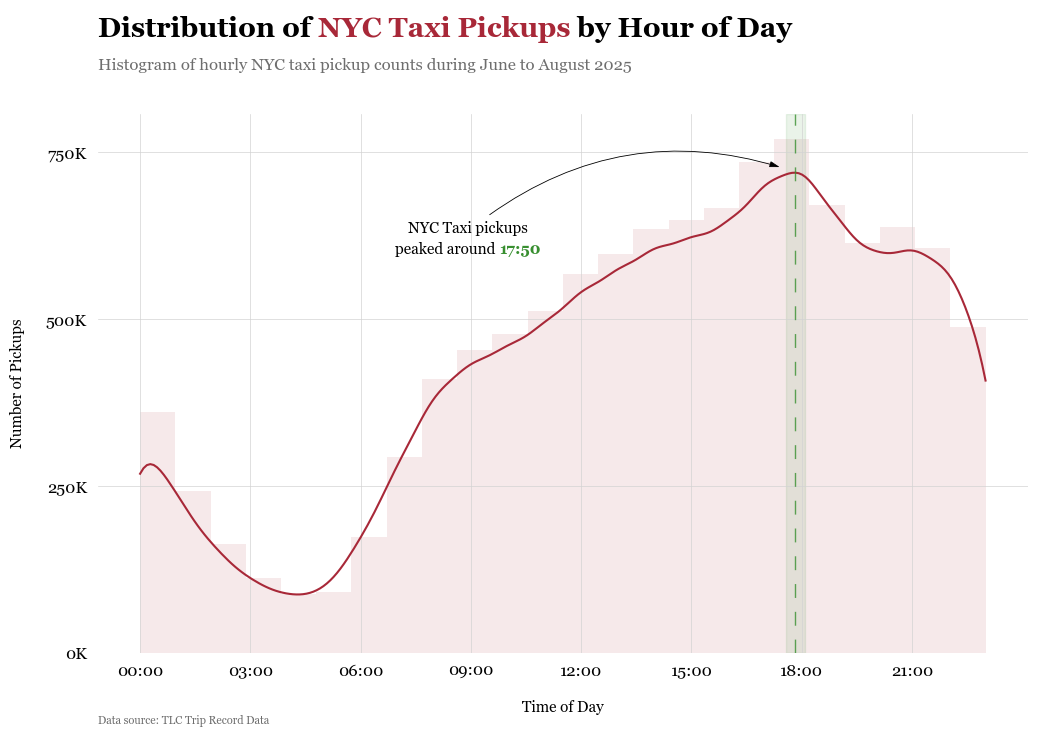

In [101]:
# define colour palette
cmap = load_cmap("groudon")
colours = cmap.colors
line_colour = colours[4]
highlight_colour = "#388F30FF"

# create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# refine appearance of axes
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(
    axis="both",
    length=0,
    pad=8,
    labelsize=12
)

# set x-axis ticks (time of day)
x_range = np.arange(0, 24, 3)
ax.set_xticks(x_range)

xtick_labels = [f"{int(x):02d}:00" for x in x_range]
ax.set_xticklabels(xtick_labels)

# set y-axis tick frequency
ax.yaxis.set_major_locator(
    mticker.MaxNLocator(nbins=4)
)

# format y-axis in thousands
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}K")
)

# add gridlines (both axes for KDE)
ax.grid(
    axis="both",
    color="lightgrey",
    linewidth=0.5,
    zorder=0
)

# axis labels
ax.set_xlabel(
    "Time of Day",
    labelpad=15
)
ax.set_ylabel(
    "Number of Pickups",
    labelpad=15
)

# plot histogram (counts)
counts, bins, _ = ax.hist(
    data,
    bins=24,                  # adjustable bin size
    color=line_colour,
    edgecolor=None,
    linewidth=0.6,
    alpha=0.1
)

# scale KDE to histogram counts
bin_width = bins[1] - bins[0]
y_kde_scaled = y_kde * data.shape[0] * bin_width

# plot KDE line
ax.plot(
    x_kde,
    y_kde_scaled,
    color=line_colour,
    linewidth=1.5
)

# identify peak pickup hour
peak_idx = np.argmax(y_kde_scaled)
x_peak = x_kde[peak_idx]
y_peak = y_kde_scaled[peak_idx]

# add vertical reference line at peak
ax.axvline(
    x=x_peak,
    linestyle=(0, (10, 10)),
    color=highlight_colour,
    alpha=0.8
)

# add shaded band around peak
ax.axvspan(
    x_peak * 0.985,
    x_peak * 1.015,
    color=highlight_colour,
    alpha=0.1
)

# draw arrow pointing to peak
x_head, y_head = x_peak, y_peak
x_tail, y_tail = x_peak * 0.5, y_peak * 0.9
ax_arrow(
    head_position=(x_head * .98, y_head * 1.01),
    tail_position=(x_tail * 1.06, y_tail * 1.01),
    fill_head=True,
    head_width=1.8,
    head_length=6,
    color="black",
    radius=-0.25,
    width=0.6,
    mutation_scale=1,
    zorder=5
)

# compute hour + minute from peak value
peak_hour = int(x_peak)
peak_minute = int(round((x_peak - peak_hour) * 60))

# handle edge case where rounding pushes to next hour
if peak_minute == 60:
    peak_hour = (peak_hour + 1) % 24
    peak_minute = 0

# annotation text with highlighted peak time
ax_text(
    x=x_tail,
    y=y_tail,
    s=f"NYC Taxi pickups\npeaked around <{peak_hour:02d}:{peak_minute:02d}>",
    highlight_textprops=[
        {"color": highlight_colour, "weight": "bold"},
    ],
    fontsize=11,
    ha="center",
    va="top",
    textalign="center"
)

# chart title
x_title, y_title = 0.125, 1.02
fig_text(
    x=x_title, y=y_title,
    s="Distribution of <NYC Taxi Pickups> by Hour of Day",
    highlight_textprops=[
        {"color": line_colour, "weight": "bold"},
    ],
    fontsize=20,
    weight="bold"
)

# chart subtitle
fig.text(
    x=x_title, y=y_title * 0.925,
    s="Histogram of hourly NYC taxi pickup counts during June to August 2025",
    size=12,
    color="#6e6e6e"
)

# caption
fig.text(
    x=x_title,
    y=0.005,
    s="Data source: TLC Trip Record Data",
    ha="left",
    va="bottom",
    fontsize=8,
    color="#6e6e6e",
)

# save figure
plt.savefig(
    "../images/trips_by_pickup_hour.svg",
    bbox_inches="tight"
)

plt.show()